In [97]:
from dotenv import load_dotenv

load_dotenv()

True

In [ ]:
from langchain_ollama import ChatOllama
from langchain.agents import create_agent

In [33]:
!pip install --pre -U langchain langchain-openai

     -------------------------------------- 106.4/106.4 kB 1.0 MB/s eta 0:00:00
     ---------------------------------------- 84.8/84.8 kB 4.7 MB/s eta 0:00:00
  Attempting uninstall: langchain-openai
    Found existing installation: langchain-openai 1.1.6
    Uninstalling langchain-openai-1.1.6:
      Successfully uninstalled langchain-openai-1.1.6
  Attempting uninstall: langchain
    Found existing installation: langchain 1.2.1
    Uninstalling langchain-1.2.1:
      Successfully uninstalled langchain-1.2.1



[notice] A new release of pip available: 22.3 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [90]:
from dotenv import load_dotenv

load_dotenv()

True

In [99]:
import sys
import os

sys.path.append(os.path.abspath(".."))
import tools

In [ ]:
from langsmith import Client
import os

client = Client(
    api_key=os.environ["LANGSMITH_API_KEY"],
)

In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()  # loads .env

# Force LangChain to read env variables
os.environ["LANGCHAIN_TRACING_V2"] = os.getenv("LANGCHAIN_TRACING_V2", "false").lower()
if os.getenv("LANGSMITH_API_KEY"):
    os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY", "")
os.environ["LANGCHAIN_PROJECT"] = os.getenv("LANGCHAIN_PROJECT", "default")
os.environ["LANGSMITH_ENDPOINT"] = os.getenv(
    "LANGSMITH_ENDPOINT", "https://api.smith.langchain.com"
)

In [104]:
tools.calculate.invoke("3*4+2-10/20")

'3*4+2-10/20 = 13.5'

Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019ba15e-fd77-7331-8e66-70a4f346682b,id=019ba15e-fd77-7331-8e66-70a4f346682b; trace=019ba15e-fd77-7331-8e66-70a4f346682b,id=019ba15e-fd77-7331-8e66-70a4f346682b


In [ ]:
model = ChatOllama(
    model="qwen3:4b",
    base_url="http://localhost:11434",
    temperature=0,  # Low temperature for consistent math results
)

In [129]:
agent = create_agent(model, tools=[tools.calculate])

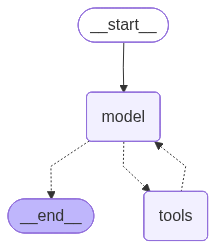

In [130]:
agent

In [ ]:
# Test agent

result = agent.invoke(
    {"messages": "What's (15 * 27) + 100 ?", "return_only_outputs": True}
)

Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019ba178-d5aa-7183-9a04-9311a4d2630b,id=019ba178-d5aa-7183-9a04-9311a4d2630b; trace=019ba178-d5aa-7183-9a04-9311a4d2630b,id=019ba178-d5ac-7493-afcb-c5414488b9a4; trace=019ba178-d5aa-7183-9a04-9311a4d2630b,id=019ba178-d5ae-7222-9868-9c1655a09945
Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019ba178-d5aa-7183-9a04-9311a4d2630b,id=019ba178-d5ae-7222-9868-9c1655a09945; trace=019ba178-d5aa-7183-9a04-9311a4d2630b,id=019ba178-d5ac-7493-afcb-c5414488b9a4; trace=019ba178-

Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019ba178-d5aa-7183-9a04-9311a4d2630b,id=019ba179-d8cd-7933-97c8-8fcf14510d39; trace=019ba178-d5aa-7183-9a04-9311a4d2630b,id=019ba179-d8c9-7b71-8018-b15cd64cd2ad; trace=019ba178-d5aa-7183-9a04-9311a4d2630b,id=019ba178-d5aa-7183-9a04-9311a4d2630b


In [132]:
print(result)

{'messages': [HumanMessage(content="What's (15 * 27) + 100 ?", additional_kwargs={}, response_metadata={}, id='47cd16b2-33b0-4223-801f-eeb57a9dac13'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3:4b', 'created_at': '2026-01-09T06:37:55.7747568Z', 'done': True, 'done_reason': 'stop', 'total_duration': 64284099300, 'load_duration': 79243900, 'prompt_eval_count': 206, 'prompt_eval_duration': 4929186900, 'eval_count': 454, 'eval_duration': 59163006600, 'logprobs': None, 'model_name': 'qwen3:4b', 'model_provider': 'ollama'}, id='lc_run--019ba178-d5ae-7222-9868-9c1655a09945-0', tool_calls=[{'name': 'calculate', 'args': {'expression': '(15 * 27) + 100'}, 'id': 'bdc4d4ef-6980-41c9-b2e2-b618a581d27a', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 206, 'output_tokens': 454, 'total_tokens': 660}), ToolMessage(content='(15 * 27) + 100 = 505', name='calculate', id='7142e818-9386-425a-944e-3af9e7d5ee91', tool_call_id='bdc4d4ef-6980-41

In [133]:
print(f"Response : {result['messages'][-1].content}")

Response : The result of the expression $(15 \times 27) + 100$ is **505**.


In [ ]:
result["messages"][-1].pretty_print()

================================== Ai Message ==================================

The result of the expression $(15 \times 27) + 100$ is **505**.


In [135]:
question = "Explain what 2 + 2 equals and show your reasoning"

# Configuration 1

In [148]:
# Configuration 1: Conservative/Deterministic - for consistent, reliable output

print(
    "== Configuration 1: Conservative/Deterministic - for consistent, reliable output ==="
)
llm1 = ChatOllama(
    model="qwen3:4b",
    temperature=0,  # Low temperature for consistency
    top_p=1,        # Focus on must probable tokens
    repeat_penalty=1.1, # Slight repetition penalty
    num_predict=500, # Reasonable output length
    num_ctx=4096, # Standard context window
    seed=42
)

agent = create_agent(llm1, tools=[tools.calculate, tools.web_search])
result = agent.invoke({'messages': question})


== Configuration 1: Conservative/Deterministic - for consistent, reliable output ===


Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019ba1f9-bb4c-7ec2-b99d-6a0c5e69423f,id=019ba1f9-bb4c-7ec2-b99d-6a0c5e69423f; trace=019ba1f9-bb4c-7ec2-b99d-6a0c5e69423f,id=019ba1f9-bb4e-7071-a232-fa8279fc1658; trace=019ba1f9-bb4c-7ec2-b99d-6a0c5e69423f,id=019ba1f9-bb52-7f31-9fd7-2a71ed49ee45


Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019ba1f9-bb4c-7ec2-b99d-6a0c5e69423f,id=019ba1f9-bb52-7f31-9fd7-2a71ed49ee45; trace=019ba1f9-bb4c-7ec2-b99d-6a0c5e69423f,id=019ba1f9-bb4e-7071-a232-fa8279fc1658; trace=019ba1f9-bb4c-7ec2-b99d-6a0c5e69423f,id=019ba1f9-bb4c-7ec2-b99d-6a0c5e69423f


In [149]:
print(f"Conservative output: {result['messages'][-1].content}")

Conservative output: 


In [150]:
result

{'messages': [HumanMessage(content='Explain what 2 + 2 equals and show your reasoning', additional_kwargs={}, response_metadata={}, id='e2e1cdb9-bdf2-42eb-9cc6-3aca18105500'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3:4b', 'created_at': '2026-01-09T08:58:51.6704835Z', 'done': True, 'done_reason': 'length', 'total_duration': 74818561800, 'load_duration': 1911019900, 'prompt_eval_count': 308, 'prompt_eval_duration': 7456353700, 'eval_count': 500, 'eval_duration': 65319161900, 'logprobs': None, 'model_name': 'qwen3:4b', 'model_provider': 'ollama'}, id='lc_run--019ba1f9-bb52-7f31-9fd7-2a71ed49ee45-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 308, 'output_tokens': 500, 'total_tokens': 808})]}

In [151]:
print("=== Configuration with Balance/Production ===")
llm2 = ChatOllama(
    model="qwen3:4b",
    temperature=2, # Moderate creativity
    top_k=200, # Standard Token selection
    repeat_last_n=64, # Check last 64 token for repetation
    repeat_penalty=1.15, # Moderate repetition controll
    num_predict=100, # short response allowed | check output
    num_ctx=8192, # larger context for complex task
    keep_alive="5m", # keep model loaded for performance 
    num_thread=4, # Optimize for multi-core processing
)

=== Configuration with Balance/Production ===


In [152]:
agent = create_agent(llm2, tools=[tools.calculate])
result = agent.invoke({'messages':question})

Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019ba204-1f21-79f1-b05e-14675d1e7684,id=019ba204-1f21-79f1-b05e-14675d1e7684; trace=019ba204-1f21-79f1-b05e-14675d1e7684,id=019ba204-1f24-7c61-ae71-28ef53cf88b3; trace=019ba204-1f21-79f1-b05e-14675d1e7684,id=019ba204-1f27-7713-af3c-b8f97333a677


Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019ba204-1f21-79f1-b05e-14675d1e7684,id=019ba204-1f27-7713-af3c-b8f97333a677; trace=019ba204-1f21-79f1-b05e-14675d1e7684,id=019ba204-1f24-7c61-ae71-28ef53cf88b3; trace=019ba204-1f21-79f1-b05e-14675d1e7684,id=019ba204-1f21-79f1-b05e-14675d1e7684


In [153]:
result

{'messages': [HumanMessage(content='Explain what 2 + 2 equals and show your reasoning', additional_kwargs={}, response_metadata={}, id='ff64636f-2dc0-4f08-8850-545da06783ee'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3:4b', 'created_at': '2026-01-09T09:09:19.1631333Z', 'done': True, 'done_reason': 'length', 'total_duration': 21393599400, 'load_duration': 1514258600, 'prompt_eval_count': 203, 'prompt_eval_duration': 6528822400, 'eval_count': 100, 'eval_duration': 13288962800, 'logprobs': None, 'model_name': 'qwen3:4b', 'model_provider': 'ollama'}, id='lc_run--019ba204-1f27-7713-af3c-b8f97333a677-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 203, 'output_tokens': 100, 'total_tokens': 303})]}

In [154]:
print(result['messages'][-1].content)

# Configuration 2

In [155]:
# Configuration 1: Conservative/Deterministic - for consistent, reliable output

print(
    "== Configuration 1: Conservative/Deterministic - for consistent, reliable output ==="
)
llm1 = ChatOllama(
    model="llama3.1:8b",
    temperature=0,  # Low temperature for consistency
    top_p=1,        # Focus on must probable tokens
    repeat_penalty=1.1, # Slight repetition penalty
    num_predict=500, # Reasonable output length
    num_ctx=4096, # Standard context window
    seed=42
)

agent = create_agent(llm1, tools=[tools.calculate, tools.web_search])
result = agent.invoke({'messages': question})

== Configuration 1: Conservative/Deterministic - for consistent, reliable output ===


Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019ba205-8f3c-7911-8873-6931628e225f,id=019ba205-8f3c-7911-8873-6931628e225f; trace=019ba205-8f3c-7911-8873-6931628e225f,id=019ba205-8f3e-7e11-a60f-205bc171bee5; trace=019ba205-8f3c-7911-8873-6931628e225f,id=019ba205-8f42-7112-a5bd-f09a31a314a6
Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019ba205-8f3c-7911-8873-6931628e225f,id=019ba205-8f42-7112-a5bd-f09a31a314a6; trace=019ba205-8f3c-7911-8873-6931628e225f,id=019ba205-8f3e-7e11-a60f-205bc171bee5; trace=019ba205-

Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019ba205-8f3c-7911-8873-6931628e225f,id=019ba205-ed26-79d3-84fd-37cdf80cd323; trace=019ba205-8f3c-7911-8873-6931628e225f,id=019ba205-ed20-7e11-b8c7-9d1c09d607c8; trace=019ba205-8f3c-7911-8873-6931628e225f,id=019ba205-8f3c-7911-8873-6931628e225f


In [156]:
print(f"Conservative output: {result['messages'][-1].content}")

Conservative output: The reasoning behind this is based on the fundamental principles of arithmetic. In basic addition, when you have two numbers being added together, you count up by the value of each number.

In this case, we are adding 2 and 2. To find the total, we start with the first number (2) and then add the second number (2). This means counting up from 2 by 2, which brings us to a total of 4.


In [157]:
result

{'messages': [HumanMessage(content='Explain what 2 + 2 equals and show your reasoning', additional_kwargs={}, response_metadata={}, id='1f53fb94-3190-4f92-b566-922a15a5ed27'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.1:8b', 'created_at': '2026-01-09T09:10:56.0254498Z', 'done': True, 'done_reason': 'stop', 'total_duration': 24021852000, 'load_duration': 5442638800, 'prompt_eval_count': 319, 'prompt_eval_duration': 14351699300, 'eval_count': 19, 'eval_duration': 4205140500, 'logprobs': None, 'model_name': 'llama3.1:8b', 'model_provider': 'ollama'}, id='lc_run--019ba205-8f42-7112-a5bd-f09a31a314a6-0', tool_calls=[{'name': 'calculate', 'args': {'expression': '2 + 2'}, 'id': '342672fb-2ff2-4254-a3f1-f8474e4f1e05', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 319, 'output_tokens': 19, 'total_tokens': 338}),
  ToolMessage(content='2 + 2 = 4', name='calculate', id='7808969c-5271-400d-af54-3f771af41478', tool_call_id='342

In [169]:
print("=== Configuration with Balance/Production ===")
llm2 = ChatOllama(
    model="llama3.1:8b",
    temperature=3, # Moderate creativity
    top_k=2000, # Standard Token selection
    repeat_last_n=64, # Check last 64 token for repetation
    repeat_penalty=1.15, # Moderate repetition controll
    num_predict=1000, # short response allowed | check output
    num_ctx=8192, # larger context for complex task
    keep_alive="5m", # keep model loaded for performance 
    num_thread=4, # Optimize for multi-core processing
)

=== Configuration with Balance/Production ===


In [170]:
agent = create_agent(llm2, tools=[tools.calculate, tools.web_search])
result = agent.invoke({'messages': question})

Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019ba213-9873-7ea3-8487-5243cc32b826,id=019ba213-9873-7ea3-8487-5243cc32b826; trace=019ba213-9873-7ea3-8487-5243cc32b826,id=019ba213-9876-74c1-90b6-fd1581538c89; trace=019ba213-9873-7ea3-8487-5243cc32b826,id=019ba213-987c-7522-bef4-bf80479dccfa
Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019ba213-9873-7ea3-8487-5243cc32b826,id=019ba213-987c-7522-bef4-bf80479dccfa; trace=019ba213-9873-7ea3-8487-5243cc32b826,id=019ba213-9876-74c1-90b6-fd1581538c89; trace=019ba213-

Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019ba213-9873-7ea3-8487-5243cc32b826,id=019ba213-e774-7841-a722-78c5d07d5d04; trace=019ba213-9873-7ea3-8487-5243cc32b826,id=019ba213-e771-7f22-a4bc-7686e870b2df; trace=019ba213-9873-7ea3-8487-5243cc32b826,id=019ba213-9873-7ea3-8487-5243cc32b826


In [171]:
print(f" Balance/Production output: {result['messages'][-1].content}")

 Balance/Production output: The equation 2 + 2 can be evaluated using basic arithmetic rules. When adding two numbers, the quantities being added are combined as one quantity.

For example:

• Imagine having 2 apples and gaining 2 more.
In this scenario, you would have a total of 4 apples.

This understanding is consistent with our expectation in math when dealing with basic addition like in 1+1=2 or indeed when considering 2 + 2. The result aligns well with common-sense counting methods too as adding the individual units adds to your complete sum hence confirming we must reach 4 following our exploration on explanation based decisionmaking.

This equality can also be explained mathematically through formulas such like

*   a+b=c

In that case both elements need incorporation giving totaling c figure

Both clearly mean under "Number system Common" integer model numbers move counting we treat term universally more give factor don as high universal two desired summary everyone way either